In [1]:
!pip install --upgrade transformers accelerate diffusers huggingface_hub tokenizers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56

In [2]:
import os
import re
import sys
import math

import torch 
import torch.nn as nn
from transformers import PreTrainedModel, PretrainedConfig, AutoModel, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import TensorDataset, random_split
from transformers import BertForSequenceClassification

import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import random

import glob
from bs4 import BeautifulSoup
from collections import Counter


import warnings
warnings.filterwarnings('ignore')

2025-11-05 12:45:55.901337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762346756.094065      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762346756.151458      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")


Device: cuda


In [5]:
def global_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

global_seed(42)

In [6]:
train_df = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-class/train.csv')
test_df = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-class/test.csv')
labels = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-class/test_labels.csv')
model_path = '/kaggle/input/roberta-epoch5/pytorch/default/1/bert_epoch_5.pth'

In [7]:
labels.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [8]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [9]:
train_df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
label_counts = train_df[label_columns].sum()
label_counts

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

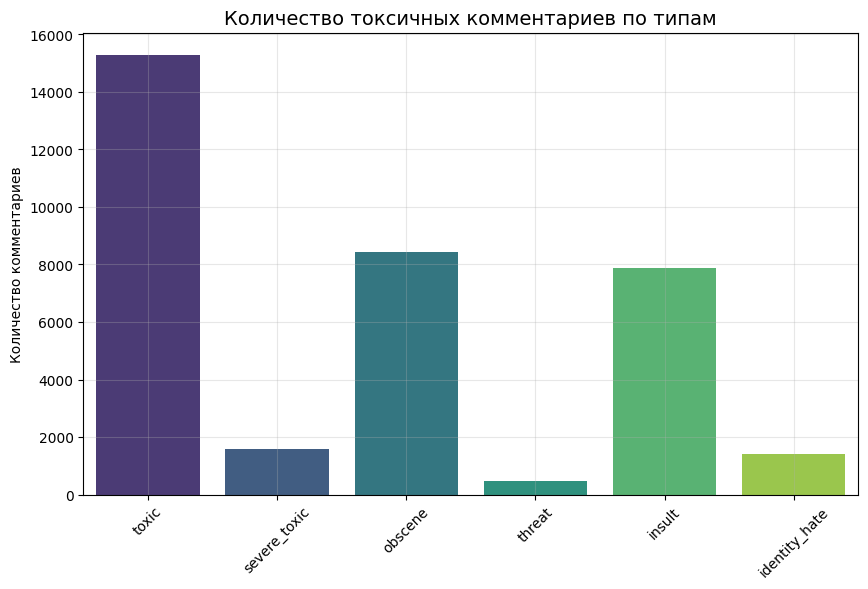

In [11]:
# Визуализация распределения классов
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title('Количество токсичных комментариев по типам', fontsize=14)
plt.ylabel('Количество комментариев')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Процентное соотношение
total_comments = len(train_df)
label_percentages = (label_counts / total_comments) * 100
print(f"\nПроцентное соотношение (от общего числа комментариев):")
for label, pct in label_percentages.items():
    print(f" {label}: {pct:.2f}%")



Процентное соотношение (от общего числа комментариев):
 toxic: 9.58%
 severe_toxic: 1.00%
 obscene: 5.29%
 threat: 0.30%
 insult: 4.94%
 identity_hate: 0.88%


## Анализ длины текстов

In [13]:
train_df['char_count'] = train_df['comment_text'].apply(len)
train_df['word_count'] = train_df['comment_text'].apply(lambda x: len(x.split()))
train_df['sentence_count'] = train_df['comment_text'].apply(lambda x: len(re.split(r'[.!?]+', x)) - 1 if x else 0)

In [14]:
print("\nСтатистика по длине текстов:")
print(train_df[['char_count', 'word_count', 'sentence_count']].describe())


Статистика по длине текстов:
          char_count     word_count  sentence_count
count  159571.000000  159571.000000   159571.000000
mean      394.073221      67.273527        4.659130
std       590.720282      99.230702        8.102081
min         6.000000       1.000000        0.000000
25%        96.000000      17.000000        1.000000
50%       205.000000      36.000000        3.000000
75%       435.000000      75.000000        5.000000
max      5000.000000    1411.000000      683.000000


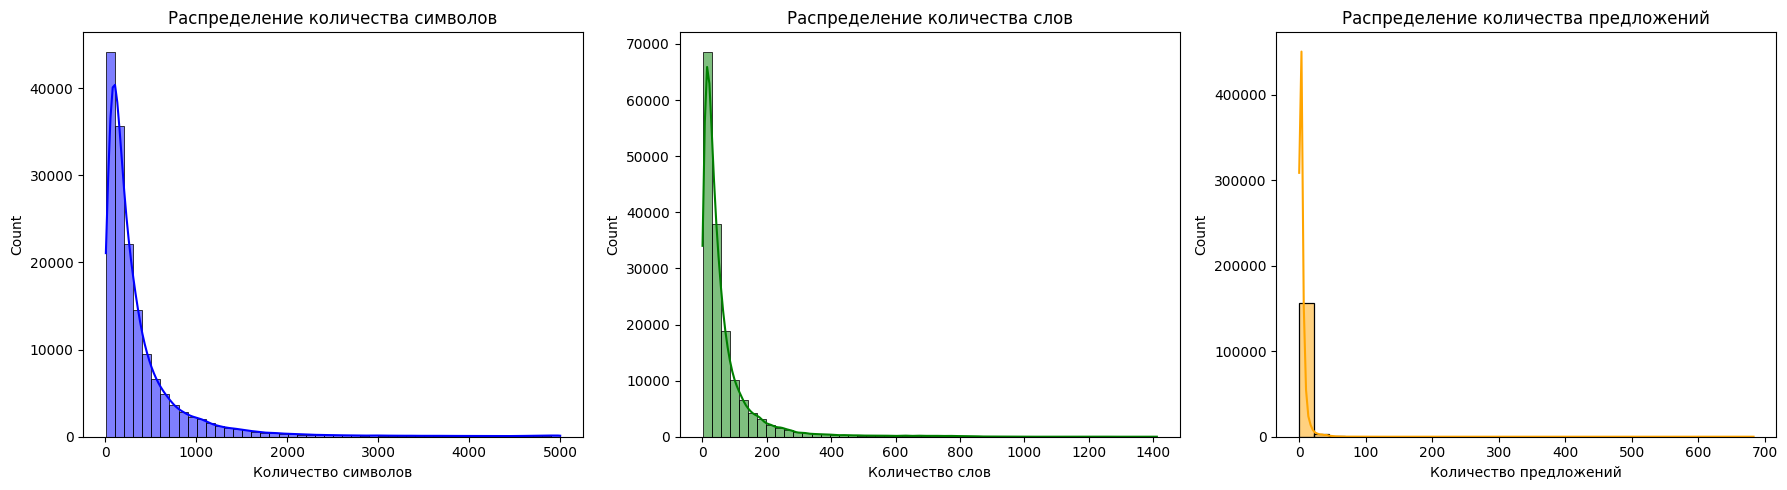

In [15]:
# Визуализация распределения длины
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(train_df['char_count'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Распределение количества символов')
axes[0].set_xlabel('Количество символов')

sns.histplot(train_df['word_count'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Распределение количества слов')
axes[1].set_xlabel('Количество слов')

sns.histplot(train_df['sentence_count'], bins=30, kde=True, ax=axes[2], color='orange')
axes[2].set_title('Распределение количества предложений')
axes[2].set_xlabel('Количество предложений')

plt.tight_layout()
plt.show()

## Частотный анализ: слов и n-грамм

In [16]:
# Функция для получения топ-N слов
def get_top_n_words(text_series, n=20):
    all_words = ' '.join(text_series).lower().split()
    # Удаляем знаки препинания и цифры
    all_words = [re.sub(r'[^a-zA-Z]', '', word) for word in all_words]
    all_words = [word for word in all_words if len(word) > 2] # Убираем очень короткие слова
    word_freq = pd.Series(all_words).value_counts().head(n)
    return word_freq

In [17]:
# Топ-20 слов во всем датасете
top_words_all = get_top_n_words(train_df['comment_text'])
print("\nТоп-20 самых частых слов во всем датасете:")
print(top_words_all)

# Топ-20 слов для каждого класса
for label in label_columns:
    print(f"\nТоп-20 слов в комментариях с меткой '{label}':")
    toxic_comments = train_df[train_df[label] == 1]['comment_text']
    if len(toxic_comments) > 0:
        top_words_label = get_top_n_words(toxic_comments)
        print(top_words_label)
    else:
        print("  Нет комментариев с этой меткой.")


Топ-20 самых частых слов во всем датасете:
the          495480
and          222368
you          204560
that         154301
for          102445
this          97081
not           93338
have          72173
are           71876
your          63253
with          59498
article       55434
was           54487
but           50753
page          45669
from          41417
about         37049
wikipedia     35601
can           33993
what          33736
Name: count, dtype: int64

Топ-20 слов в комментариях с меткой 'toxic':
you          35329
the          20451
and          15647
your          9114
fuck          8617
are           8153
that          7736
this          5432
not           4809
for           4705
have          4609
with          3916
shit          3587
dont          3566
like          3478
all           3432
nigger        3289
wikipedia     3263
fucking       3194
what          3189
Name: count, dtype: int64

Топ-20 слов в комментариях с меткой 'severe_toxic':
you          9669
fuck   

In [18]:
%%time
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

# Убедимся, что токенизатор загружен
nltk.download('punkt', quiet=True)

def get_top_ngrams(text_series, n=2, top_k=20):
    all_tokens = []
    for text in text_series:
        if pd.isna(text):
            continue
        # Токенизируем и приводим к нижнему регистру
        tokens = word_tokenize(text.lower())
        # Убираем неалфавитные токены (оставляем только слова)
        tokens = [re.sub(r'[^a-z]', '', token) for token in tokens]
        tokens = [token for token in tokens if len(token) > 2 and token.isalpha()]
        all_tokens.extend(tokens)
    
    # Генерируем n-граммы
    n_grams = list(ngrams(all_tokens, n))
    # Считаем частоты
    ngram_freq = Counter(n_grams)
    return ngram_freq.most_common(top_k)

# Анализ bigrams и trigrams для всего датасета
print("\nТоп-15 биграмм во всем датасете:")
top_bigrams_all = get_top_ngrams(train_df['comment_text'], n=2, top_k=15)
for ngram, freq in top_bigrams_all:
    print(f"{' '.join(ngram)}: {freq}")

print("\nТоп-15 триграмм во всем датасете:")
top_trigrams_all = get_top_ngrams(train_df['comment_text'], n=3, top_k=15)
for ngram, freq in top_trigrams_all:
    print(f"{' '.join(ngram)}: {freq}")

# Анализ n-грамм для каждого токсичного класса
for label in label_columns:
    toxic_texts = train_df[train_df[label] == 1]['comment_text']
    if len(toxic_texts) > 0:
        print(f"\nТоп-10 биграмм для класса '{label}':")
        top_bigrams_label = get_top_ngrams(toxic_texts, n=2, top_k=10)
        for ngram, freq in top_bigrams_label:
            print(f"  {' '.join(ngram)}: {freq}")


Топ-15 биграмм во всем датасете:
the article: 24072
you are: 17586
that the: 15262
for the: 14647
you have: 14610
and the: 14096
talk page: 13301
that you: 11580
with the: 10863
you can: 10062
has been: 9674
thank you: 9526
from the: 9172
this article: 8668
have been: 7866

Топ-15 триграмм во всем датасете:
thank you for: 4027
the talk page: 2591
the fact that: 2397
blocked from editing: 2297
you have any: 2124
for speedy deletion: 2069
you for your: 2010
nigger nigger nigger: 2007
you will blocked: 1903
will blocked from: 1801
you would like: 1671
have any questions: 1599
you fuck you: 1585
fuck you fuck: 1584
your talk page: 1501

Топ-10 биграмм для класса 'toxic':
  you are: 4380
  fuck you: 3821
  nigger nigger: 2015
  you fuck: 1782
  moron moron: 1469
  pig pig: 1249
  jew fat: 1234
  fat jew: 1226
  you suck: 1178
  shit shit: 1147

Топ-10 биграмм для класса 'severe_toxic':
  fuck you: 3119
  you fuck: 1599
  you suck: 1033
  shit shit: 1000
  you are: 903
  fuck yourself: 895


## Выявление выбросов



In [19]:
# Ищем очень длинные комментарии (выбросы)
Q1_char = train_df['char_count'].quantile(0.25)
Q3_char = train_df['char_count'].quantile(0.75)
IQR_char = Q3_char - Q1_char
upper_bound_char = Q3_char + 1.5 * IQR_char

outliers_char = train_df[train_df['char_count'] > upper_bound_char]
print(f"\nКоличество комментариев-выбросов по длине (символы): {len(outliers_char)}")
if len(outliers_char) > 0:
    print("Примеры самых длинных комментариев:")
    print(outliers_char[['comment_text', 'char_count']].head(3))

# Ищем очень короткие комментарии (возможно, аномалии)
short_comments = train_df[train_df['word_count'] < 3]
print(f"\nКоличество очень коротких комментариев (< 3 слов): {len(short_comments)}")
if len(short_comments) > 0:
    print("Примеры очень коротких комментариев:")
    print(short_comments[['comment_text', 'word_count']].head(3))


Количество комментариев-выбросов по длине (символы): 14658
Примеры самых длинных комментариев:
                                         comment_text  char_count
10  "\nFair use rationale for Image:Wonju.jpg\n\nT...        2875
24  "\n\nRe-considering 1st paragraph edit?\nI don...        1409
36  "\n\n ""Mainland Asia"" includes ""the lower b...        1289

Количество очень коротких комментариев (< 3 слов): 165
Примеры очень коротких комментариев:
                                comment_text  word_count
2247  [[User_Talk:King Lopez|Lopez]]Contribs           2
2981                     cocksucking bastard           2
3638                          September 2008           2


## Визуализация

### Word clouds

In [20]:
from wordcloud import WordCloud
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


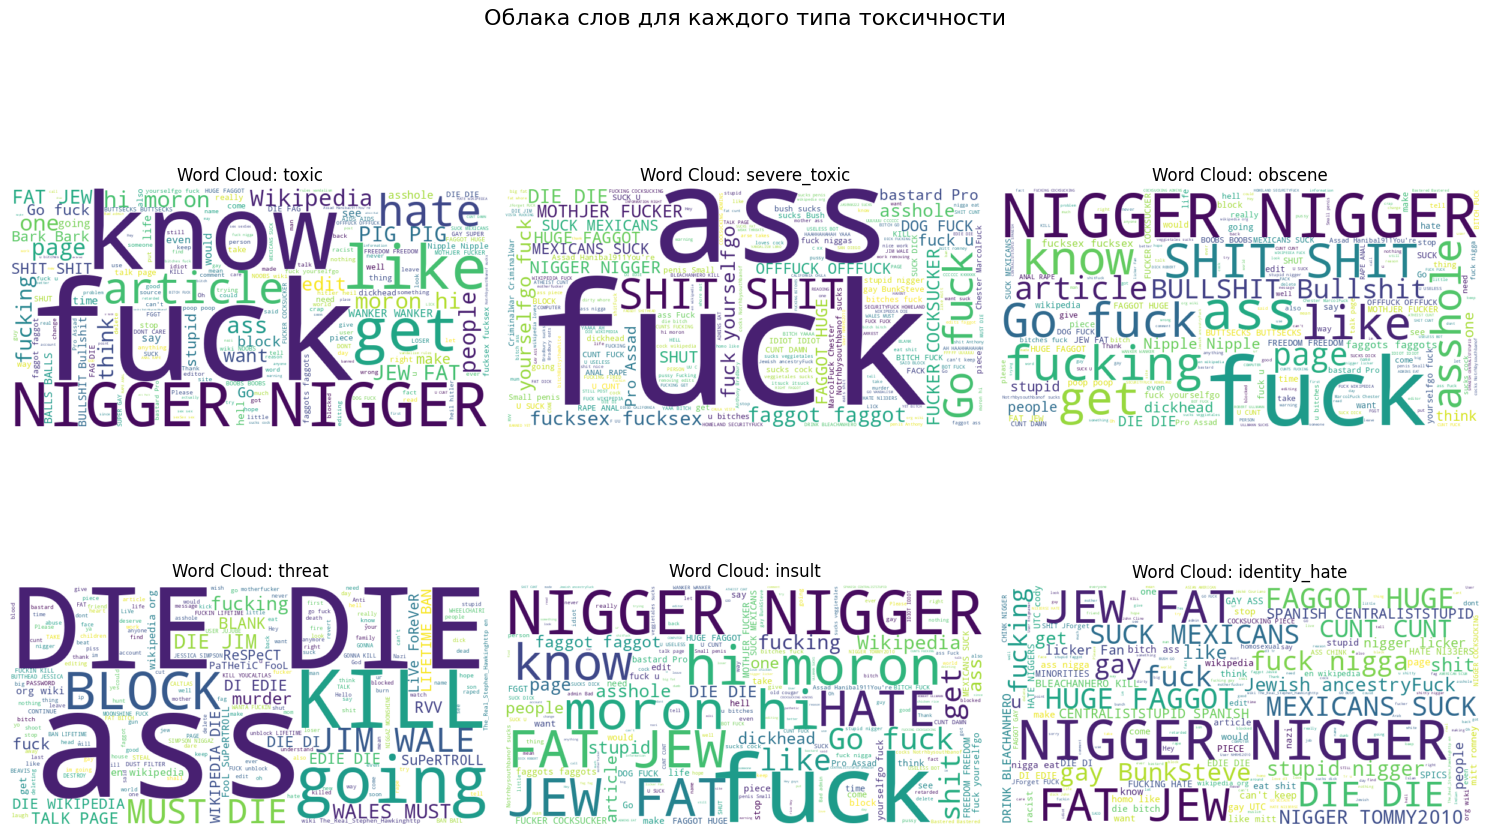

In [21]:
%matplotlib inline


# Создаем фигуру
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, label in enumerate(label_columns):
    # Формируем текст для облака слов
    text_for_cloud = ' '.join(train_df[train_df[label] == 1]['comment_text'].astype(str))
    if text_for_cloud.strip(): # Проверяем, что текст не пустой
        wordcloud = WordCloud(width=800, height=400, background_color='white',
                              max_words=200, stopwords=stop_words, random_state=42).generate(text_for_cloud)
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'Word Cloud: {label}', fontsize=12)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'Нет данных для {label}', ha='center', va='center', fontsize=12)
        axes[i].axis('off')

plt.suptitle('Облака слов для каждого типа токсичности', fontsize=16)
plt.tight_layout()
plt.show()

### Распределение длин текстов

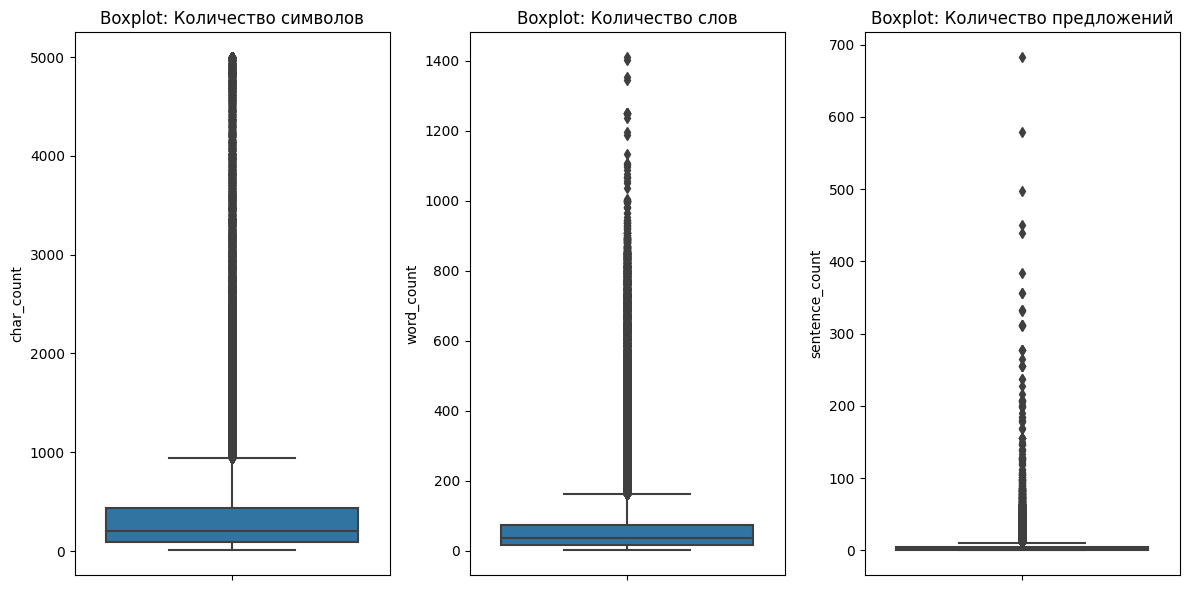

In [22]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=train_df['char_count'])
plt.title('Boxplot: Количество символов')

plt.subplot(1, 3, 2)
sns.boxplot(y=train_df['word_count'])
plt.title('Boxplot: Количество слов')

plt.subplot(1, 3, 3)
sns.boxplot(y=train_df['sentence_count'])
plt.title('Boxplot: Количество предложений')

plt.tight_layout()
plt.show()

### Корреляционная матрица признаков

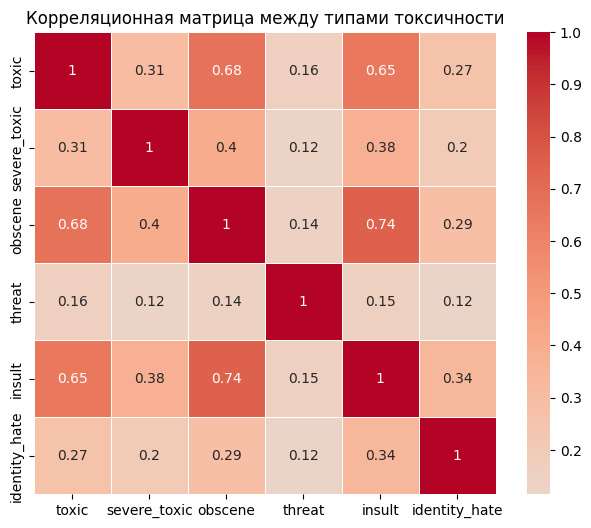


Корреляция между типами токсичности:
                  toxic  severe_toxic   obscene    threat    insult  \
toxic          1.000000      0.308619  0.676515  0.157058  0.647518   
severe_toxic   0.308619      1.000000  0.403014  0.123601  0.375807   
obscene        0.676515      0.403014  1.000000  0.141179  0.741272   
threat         0.157058      0.123601  0.141179  1.000000  0.150022   
insult         0.647518      0.375807  0.741272  0.150022  1.000000   
identity_hate  0.266009      0.201600  0.286867  0.115128  0.337736   

               identity_hate  
toxic               0.266009  
severe_toxic        0.201600  
obscene             0.286867  
threat              0.115128  
insult              0.337736  
identity_hate       1.000000  


In [23]:
# Рассчитываем корреляцию между целевыми переменными
correlation_matrix = train_df[label_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица между типами токсичности')
plt.show()

print("\nКорреляция между типами токсичности:")
print(correlation_matrix)

### t-SNE/UMAP визуализация эмбеддингов (пример с простым TF-IDF)

In [24]:
!pip install --upgrade umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 65.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.


In [25]:
!pip install --upgrade scikit-learn

In [26]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.manifold import TSNE
# import umap  
# import time

# try:
#     from sklearn.utils import check_array as sklearn_check_array

#     def patched_check_array(*args, **kwargs):
#         if 'ensure_all_finite' in kwargs:
#             del kwargs['ensure_all_finite']
#         return sklearn_check_array(*args, **kwargs)

#     umap.umap_.check_array = patched_check_array
#     print("✅ Патч для umap.apply успешно применён.")
# except Exception as e:
#     print(f"⚠️ Не удалось применить патч: {e}")


# # Используем небольшую выборку для быстрого отображения
# sample_size = 5000
# sample_df = train_df.sample(n=sample_size, random_state=42).copy()

# # TF-IDF векторизация
# print("Векторизация текстов с помощью TF-IDF...")
# tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
# X_tfidf = tfidf.fit_transform(sample_df['comment_text'])

# # Целевая метка (для визуализации)
# y_sample = sample_df['toxic'].map({0: 'Non-Toxic', 1: 'Toxic'}).values

# # === t-SNE ===
# print("Вычисление t-SNE...")
# start_time = time.time()
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
# X_tsne = tsne.fit_transform(X_tfidf.toarray())
# tsne_time = time.time() - start_time

# # === UMAP ===
# print("Вычисление UMAP...")
# start_time = time.time()
# umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
# X_umap = umap_reducer.fit_transform(X_tfidf)
# umap_time = time.time() - start_time

# # === Визуализация ===
# print(f"\nВремя выполнения:\n- t-SNE: {tsne_time:.2f} сек\n- UMAP:  {umap_time:.2f} сек")

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# # t-SNE
# axes[0].scatter(X_tsne[y_sample == 'Non-Toxic', 0], X_tsne[y_sample == 'Non-Toxic', 1],
#                 c='blue', label='Non-Toxic', alpha=0.6, s=10)
# axes[0].scatter(X_tsne[y_sample == 'Toxic', 0], X_tsne[y_sample == 'Toxic', 1],
#                 c='red', label='Toxic', alpha=0.8, s=15)
# axes[0].set_title('t-SNE: TF-IDF Embeddings', fontsize=14)
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # UMAP
# axes[1].scatter(X_umap[y_sample == 'Non-Toxic', 0], X_umap[y_sample == 'Non-Toxic', 1],
#                 c='blue', label='Non-Toxic', alpha=0.6, s=10)
# axes[1].scatter(X_umap[y_sample == 'Toxic', 0], X_umap[y_sample == 'Toxic', 1],
#                 c='red', label='Toxic', alpha=0.8, s=15)
# axes[1].set_title('UMAP: TF-IDF Embeddings', fontsize=14)
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.suptitle('Сравнение t-SNE и UMAP для визуализации токсичных комментариев', fontsize=16)
# plt.tight_layout()
# plt.show()

# Выводы из анализа
1. **Сложность задачи и потенциальные проблемы:**
   - Задача является многометочной и крайне несбалансированной. Модель может "обмануть" метрику точности, просто предсказывая 0 для всех классов.
   - Необходимо использовать метрики, устойчивые к дисбалансу (AUC-ROC, F1-score).
   - Данные содержат шум и аномалии (очень длинные или очень короткие комментарии).

2. **Стратегии для работы с дисбалансом классов:**
   - Использовать взвешивание классов в функции потерь.
   - Применять техники oversampling (SMOTE) или undersampling.
   - Использовать ансамбли моделей.

3. **Гипотезы о полезных признаках:**
   - Длина текста (особенно количество слов и символов) может быть важным признаком.
   - Частота определенных слов и фраз (например, "fuck", "kill", "you are") сильно коррелирует с токсичностью.
   - Наличие определенных n-грамм (например, "you are a", "fuck you fuck") может быть ключевым признаком.
   - Сильная положительная корреляция между `toxic` и `insult`/`obscene` указывает на то, что эти типы часто встречаются вместе.

# Предобработка и очистка данных

## Очистка и нормализация

In [27]:
nltk.download('wordnet')
nltk.download('punkt')
from nltk.stem import WordNetLemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Функция для очистки и нормализации текста.
    """
    if not isinstance(text, str):
        return ""
    
    # Приводим к нижнему регистру
    text = text.lower()
    
    # Удаляем URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Удаляем HTML-теги
    text = re.sub(r'<.*?>', '', text)
    
    # Удаляем эмодзи и символы Unicode (не буквы/цифры)
    text = re.sub(r'[^\w\s]', '', text)
    
    # Удаляем числа
    text = re.sub(r'\d+', '', text)
    
    # Удаляем лишние пробелы
    text = ' '.join(text.split())
    
    # Токенизация
    tokens = nltk.word_tokenize(text)
    
    # Удаление стоп-слов и лемматизация
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

print("Очистка и нормализация текстов...")

# Применяем очистку к обучающему и тестовому наборам
train_df['cleaned_text'] = train_df['comment_text'].apply(clean_text)
test_df['cleaned_text'] = test_df['comment_text'].apply(clean_text)

print(f"Обработано {len(train_df)} обучающих комментариев.")
print(f"Обработано {len(test_df)} тестовых комментариев.")

# Проверяем результат
print("\nПример до и после очистки:")
print("До:", train_df['comment_text'].iloc[0])
print("После:", train_df['cleaned_text'].iloc[0])

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Очистка и нормализация текстов...
Обработано 159571 обучающих комментариев.
Обработано 153164 тестовых комментариев.

Пример до и после очистки:
До: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
После: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since retired


## Токенизация и создание входных представлений

In [28]:
from transformers import AutoTokenizer

print("\nТокенизация с помощью RoBERTa...")
max_length = 128
# Загружаем токенизатор для RoBERTa
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize_for_roberta(texts, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'  # PyTorch tensors
    )

# Токенизируем обучающие и тестовые данные
train_encodings = tokenize_for_roberta(train_df['cleaned_text'])
test_encodings = tokenize_for_roberta(test_df['cleaned_text'])

print(f"Токенизировано {len(train_df)} обучающих комментариев.")
print(f"Токенизировано {len(test_df)} тестовых комментариев.")
print(f"Максимальная длина: {max_length}")


Токенизация с помощью RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Токенизировано 159571 обучающих комментариев.
Токенизировано 153164 тестовых комментариев.
Максимальная длина: 128


## Разделение на обучающую/валидационную/тестовую выборки

In [29]:
from sklearn.model_selection import train_test_split

# --- 1. Создаём y_train ---
label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
y_train = train_df[label_columns].values  # shape: (n_samples, 6)

print(f"y_train.shape: {y_train.shape}")

# --- 2. Получаем индексы ---
indices = np.arange(len(train_df))

# --- 3. Разделяем индексы (без стратификации) ---
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# --- 4. Создаём train/val подмножества из исходных энкодингов ---
train_encodings_subset = {
    key: val[train_idx] for key, val in train_encodings.items()
}
val_encodings_subset = {
    key: val[val_idx] for key, val in train_encodings.items()
}

y_train_subset = y_train[train_idx]
y_val_subset = y_train[val_idx]

print(f"Обучающая выборка: {len(train_idx)}")
print(f"Валидационная выборка: {len(val_idx)}")
print(f"y_train_subset.shape: {y_train_subset.shape}")
print(f"y_val_subset.shape: {y_val_subset.shape}")

y_train.shape: (159571, 6)
Обучающая выборка: 127656
Валидационная выборка: 31915
y_train_subset.shape: (127656, 6)
y_val_subset.shape: (31915, 6)


# Выбор и настройка модели

В качестве базовой модели я выбрал RoBERTa, поскольку она является золотой серединой между BERT и DeBERTa-v3. Она сбалансированней и быстрей, чем эти модели. Она имеет больше параметров и обучена на большем объеме данных, чем BERT. Конечно, DeBERTa-v3 лучше нее, но она тяжеловесна. Для нее еще поддерживается Hugging Face Transformers - можно использовать AutoModelForSequenceClassification.  

In [30]:
from transformers import AutoModelForSequenceClassification

print("Загрузка модели RoBERTa...")

# Загружаем предобученную модель
model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=6,  # Количество выходных классов
    problem_type="multi_label_classification"  # Ключевой параметр для многометочной задачи
)

print(f"Модель RoBERTa загружена.")
print(f"Количество параметров: {model.num_parameters():,}")

Загрузка модели RoBERTa...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель RoBERTa загружена.
Количество параметров: 124,650,246


In [31]:
%%time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm.auto import tqdm  # <- добавлен tqdm

# --- 1. Устройство ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Модель загружена на: {device}")

# --- 2. Гиперпараметры ---
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

# --- 3. Датасеты и DataLoader'ы ---
import torch
from torch.utils.data import Dataset

class ToxicCommentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

train_dataset = ToxicCommentDataset(train_encodings_subset, y_train_subset)
val_dataset = ToxicCommentDataset(val_encodings_subset, y_val_subset)

print(f" Датасеты созданы.")
print(f" Обучающий датасет: {len(train_dataset)} примеров")
print(f" Валидационный датасет: {len(val_dataset)} примеров")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 4. Оптимизатор и scheduler ---
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# --- 5. Функция потерь ---
loss_fn = nn.BCEWithLogitsLoss()

# --- 6. Функция обучения одной эпохи ---
def train_epoch(model, data_loader, loss_fn, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    # Оборачиваем data_loader в tqdm
    progress_bar = tqdm(data_loader, desc="Обучение", leave=False)
    for batch in progress_bar:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        # Обновляем описание tqdm с текущим loss
        progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(data_loader)

# --- 7. Функция валидации ---
def eval_model(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    # Оборачиваем data_loader в tqdm
    progress_bar = tqdm(data_loader, desc="Валидация", leave=False)
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            
            preds = torch.sigmoid(outputs.logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    auc_scores = []
    for i in range(6):
        try:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(auc)
        except ValueError:
            auc_scores.append(0.5)
    
    return total_loss / len(data_loader), np.mean(auc_scores), auc_scores

# --- 8. Обучение ---
print("\n🚀 Начало обучения baseline RoBERTa с Early Stopping...")
print(f"Эпох: {EPOCHS} | Batch Size: {BATCH_SIZE} | LR: {LEARNING_RATE}")

# Параметры Early Stopping
best_val_auc = 0.0
patience = 2
epochs_no_improve = 0
early_stop = False

for epoch in range(EPOCHS):
    if early_stop:
        print(f"\n Early Stopping на эпохе {epoch}")
        break
        
    print(f'\nЭпоха {epoch + 1}/{EPOCHS}')
    
    # Обучение
    train_loss = train_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, device
    )
    
    # Валидация
    val_loss, mean_auc, auc_scores = eval_model(
        model, val_loader, loss_fn, device
    )
    
    print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    print(f'Mean AUC-ROC: {mean_auc:.4f}')
    for i, label in enumerate(label_columns):
        print(f'  {label}: {auc_scores[i]:.4f}')
    
    # --- Early Stopping Logic ---
    if mean_auc > best_val_auc:
        best_val_auc = mean_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_roberta_baseline.bin')
        print(f"  Новое лучшее значение AUC: {best_val_auc:.4f} - модель сохранена")
    else:
        epochs_no_improve += 1
        print(f"  Нет улучшения {epochs_no_improve}/{patience} эпох")
        
        if epochs_no_improve >= patience:
            early_stop = True

print(f"\nОбучение завершено! Лучший Val AUC: {best_val_auc:.4f}")

Модель загружена на: cuda
 Датасеты созданы.
 Обучающий датасет: 127656 примеров
 Валидационный датасет: 31915 примеров

🚀 Начало обучения baseline RoBERTa с Early Stopping...
Эпох: 3 | Batch Size: 16 | LR: 2e-05

Эпоха 1/3


Обучение:   0%|          | 0/7979 [00:00<?, ?it/s]

Валидация:   0%|          | 0/1995 [00:00<?, ?it/s]

Train Loss: 0.0717 | Val Loss: 0.0445
Mean AUC-ROC: 0.9828
  toxic: 0.9813
  severe_toxic: 0.9895
  obscene: 0.9926
  threat: 0.9671
  insult: 0.9841
  identity_hate: 0.9823
  Новое лучшее значение AUC: 0.9828 - модель сохранена

Эпоха 2/3


Обучение:   0%|          | 0/7979 [00:00<?, ?it/s]

Валидация:   0%|          | 0/1995 [00:00<?, ?it/s]

Train Loss: 0.0413 | Val Loss: 0.0411
Mean AUC-ROC: 0.9869
  toxic: 0.9832
  severe_toxic: 0.9900
  obscene: 0.9933
  threat: 0.9819
  insult: 0.9860
  identity_hate: 0.9870
  Новое лучшее значение AUC: 0.9869 - модель сохранена

Эпоха 3/3


Обучение:   0%|          | 0/7979 [00:00<?, ?it/s]

Валидация:   0%|          | 0/1995 [00:00<?, ?it/s]

Train Loss: 0.0336 | Val Loss: 0.0426
Mean AUC-ROC: 0.9867
  toxic: 0.9829
  severe_toxic: 0.9906
  obscene: 0.9933
  threat: 0.9784
  insult: 0.9857
  identity_hate: 0.9893
  Нет улучшения 1/2 эпох

Обучение завершено! Лучший Val AUC: 0.9869
CPU times: user 2h 37min 43s, sys: 19.4 s, total: 2h 38min 3s
Wall time: 2h 37min 50s


In [32]:
model.save_pretrained('./my_roberta_model')
tokenizer.save_pretrained('./my_roberta_model')

('./my_roberta_model/tokenizer_config.json',
 './my_roberta_model/special_tokens_map.json',
 './my_roberta_model/vocab.json',
 './my_roberta_model/merges.txt',
 './my_roberta_model/added_tokens.json',
 './my_roberta_model/tokenizer.json')

# Прогноз для бейзлайна 

In [33]:
test_df = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv')
print(f"✅ Загружено {len(test_df)} тестовых комментариев.")

# --- Шаг 2: Токенизация тестовых данных ---
test_encodings = tokenize_for_roberta(test_df['comment_text'])  # Используем исходный текст!

# --- Шаг 3: Создание тестового датасета ---
class ToxicTestDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

test_dataset = ToxicTestDataset(test_encodings)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Шаг 4: Предсказания ---
def predict(model, data_loader, device):
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits).cpu().numpy()
            all_preds.extend(preds)
    
    return np.array(all_preds)

print("Выполнение предсказаний на тестовом наборе...")
test_preds = predict(model, test_loader, device)
print(f"✅ Получено {len(test_preds)} предсказаний.")

# --- Шаг 5: Подготовка submission файла ---
submission = pd.DataFrame({
    'id': test_df['id'],  # Берём id из test.csv
    'toxic': test_preds[:, 0],
    'severe_toxic': test_preds[:, 1],
    'obscene': test_preds[:, 2],
    'threat': test_preds[:, 3],
    'insult': test_preds[:, 4],
    'identity_hate': test_preds[:, 5]
})

# Проверяем, что все значения в пределах [0, 1]
assert (submission.iloc[:, 1:] >= 0).all().all(), "Некоторые предсказания < 0"
assert (submission.iloc[:, 1:] <= 1).all().all(), "Некоторые предсказания > 1"

# Сохраняем в CSV
submission.to_csv('submission_roberta_baseline.csv', index=False)
print("✅ Файл для Kaggle сохранён: submission_roberta_baseline.csv")

# Выводим первые строки
print("\nПример предсказаний:")
print(submission.head())

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv'